# **Multi-class Classification TCGA**
## **Data Loading**

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns


import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score, silhouette_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)

from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D 



from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from scipy.optimize import linear_sum_assignment


from sklearn.preprocessing import label_binarize



In [11]:
df = pd.read_csv('tcga_filt.csv')
df.columns


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/369154440.py:1: DtypeWarning: Columns (18253,18254) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('tcga_filt.csv')


Index(['Patient_ID', 'A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2M-AS1',
       'A2ML1', 'A4GALT', 'A4GNT',
       ...
       'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3', 'psiTPTE22', 'Mutated',
       'Mutation_Type', 'Protein_Conseq', 'Functional_Conseq', 'Tumor_Type'],
      dtype='object', length=18256)

In [12]:

df = df.drop(columns=['Mutated', 'Protein_Conseq', 'Functional_Conseq', 'Tumor_Type'])

In [13]:
df = df.set_index('Patient_ID')

In [14]:
df['Mutation_Type'].value_counts()

Mutation_Type
WT     2665
SNP    1312
DEL     192
INS      66
Name: count, dtype: int64

In [16]:
# encode categories
le = LabelEncoder()
df['Mutation_Type'] = le.fit_transform(df['Mutation_Type'])
# check encoding
class_names={0: 'DEL', 1: 'INS', 2: 'SNP', 3: 'WT'}
print(class_names)
df['Mutation_Type'].value_counts()

{0: 'DEL', 1: 'INS', 2: 'SNP', 3: 'WT'}


Mutation_Type
3    2665
2    1312
0     192
1      66
Name: count, dtype: int64

Here the types of mutation are abbreviated but, substantially, are the same: 'DEL' stands for deletion, 'INS' stands for insertion, 'SNP' is the Single Nucleotide Polymorphism, and 'WT' stands for Wild type referring to silent mutation.

From the value counts we can see that the classes (types of mutation) are highly unbalanced, so we want to address this problem by trying resampling methods.

### Address unbalanceness: SMOTE (Synthetic Minority Over-sampling TEchnique)

At a high level, the SMOTE algorithm can be described as follows:
- Take difference between a sample and its nearest neighbour
- Multiply the difference by a random number between 0 and 1
- Add this difference to the sample to generate a new synthetic example in feature space
- Continue on with next nearest neighbour up to user-defined number

Instead of simply duplicating existing minority instances, SMOTE creates new ones by selecting a data point from the minority class and interpolating between it and one of its k-nearest neighbors. This is done by choosing a point along the line segment connecting the two instances, introducing variability and reducing the risk of overfitting. The result is a more balanced dataset that can improve the performance of classifiers on imbalanced classification problems.

Reference: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://medium.com/%40corymaklin/synthetic-minority-over-sampling-technique-smote-7d419696b88c&ved=2ahUKEwji8PTwqaONAxVF7rsIHWA-Cc0QFnoECD4QAQ&usg=AOvVaw2qp46UR2XbUsEIXZCCdQHH

In [18]:
X = df.drop(columns=['Mutation_Type'])
y = df['Mutation_Type'].astype('category').cat.codes

In [22]:
sm = SMOTE(random_state=42, k_neighbors=5)

In [23]:
X_res, y_res = sm.fit_resample(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [24]:
y_res.value_counts()

3    2665
0    2665
2    2665
1    2665
Name: count, dtype: int64

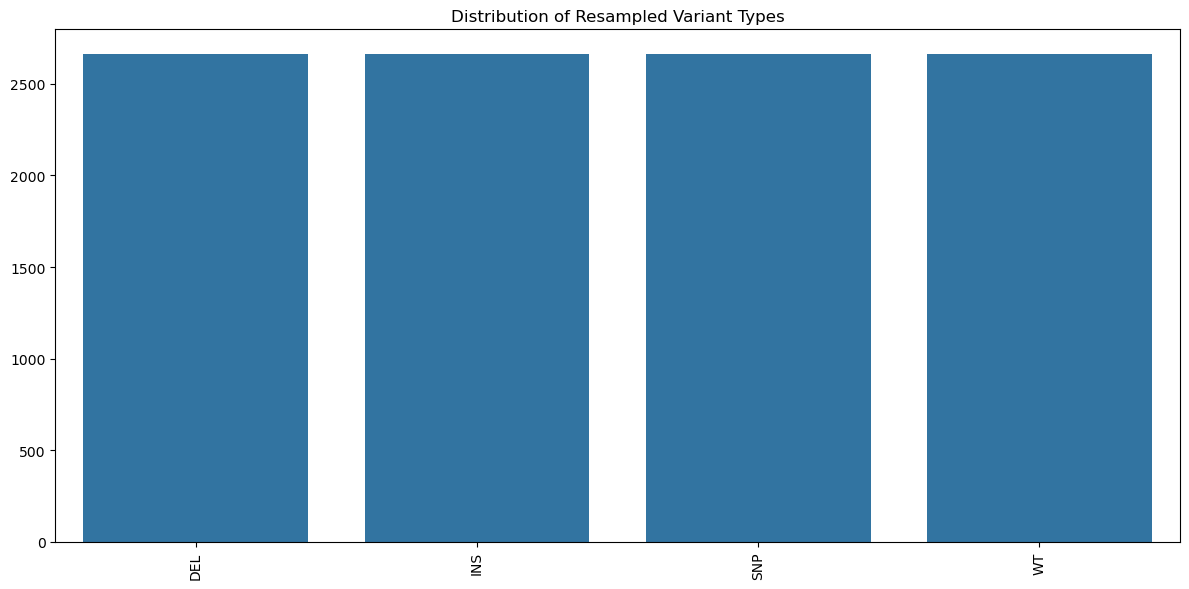

In [25]:
y_val=y_res.value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=['DEL', 'INS', 'SNP', 'WT'], y=y_val.values)
plt.xticks(rotation=90)
plt.title("Distribution of Resampled Variant Types")
plt.tight_layout()
plt.show()

Now, the classes are perfectly balanced but we want to check that the classifier won't overfit due to duplicates (perhaps created during resampling)

In [26]:
# check for duplicates and count them
duplicates = X_res[X_res.duplicated()]
duplicates_count = duplicates.shape[0]
print(f"Number of duplicates in the resampled data: {duplicates_count}")


Number of duplicates in the resampled data: 0


We don't have duplicates, therefore we proceed with pca to further investigate the visualization of the new data points.

## **PCA**

As for the other dataset, we want to visualize the data before and after resampling to see how new data appear, especially in this case that there were no duplicates and now the classes are perfectly balanced.

### **PCA before SMOTE**

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.10270341 0.05221768 0.03674819]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/609258703.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y))))
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/609258703.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


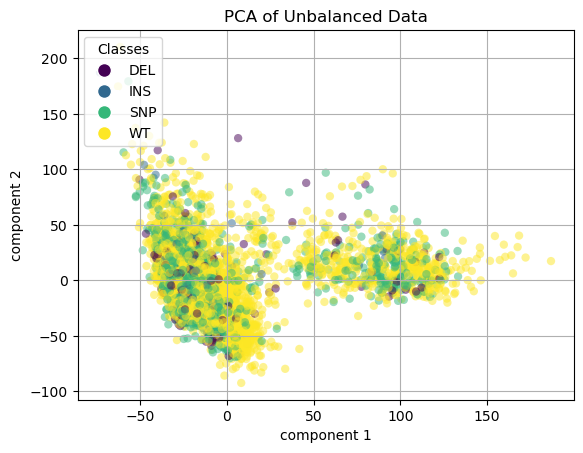

In [28]:

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y))))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Unbalanced Data')
# legend for the classes

legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.grid()

plt.show()

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/2779489231.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', len(set(y))),c=y, edgecolor='none', alpha=0.5)
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/2779489231.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


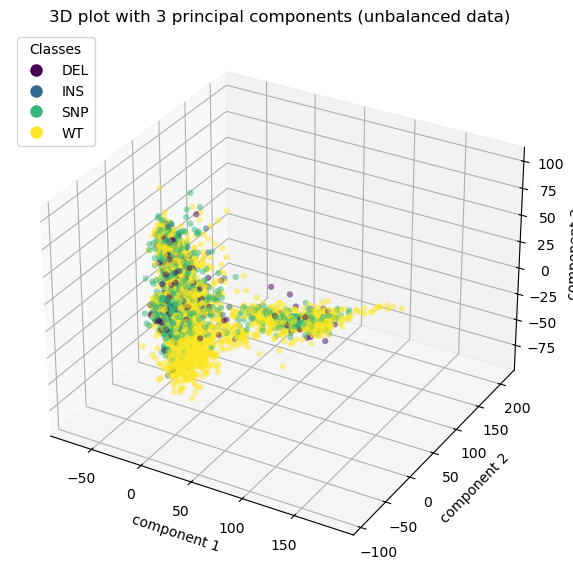

In [29]:
from mpl_toolkits.mplot3d import Axes3D 

x=X_pca[:, 0]
y1=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', len(set(y))),c=y, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components (unbalanced data)")
ax.set_xlabel('component 1')
ax.set_ylabel('component 2')
ax.set_zlabel('component 3')

# legend for the classes
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.show()


In the visualization of the unbalanced data, there's a clear dominance of yellow points (WT - wild type) and green points (SNP - single nucleotide polymorphisms), while purple (DEL - deletions) and blue (INS - insertions) are significantly underrepresented.

The wild type samples (yellow) are spread throughout the entire plot, suggesting they have diverse gene expression patterns despite being the same class. This can make sense biologically as "wild type" simply means "no relevant mutation" rather than a specific genomic state.

### **PCA after SMOTE**

In [30]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_res_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.10705096 0.05271754 0.04880134]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/2059326860.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y_res))))
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/2059326860.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


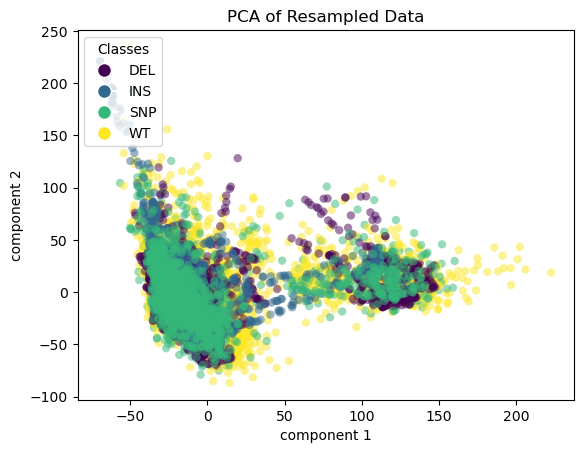

In [33]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y_res))))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Resampled Data')

legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/426136243.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/426136243.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


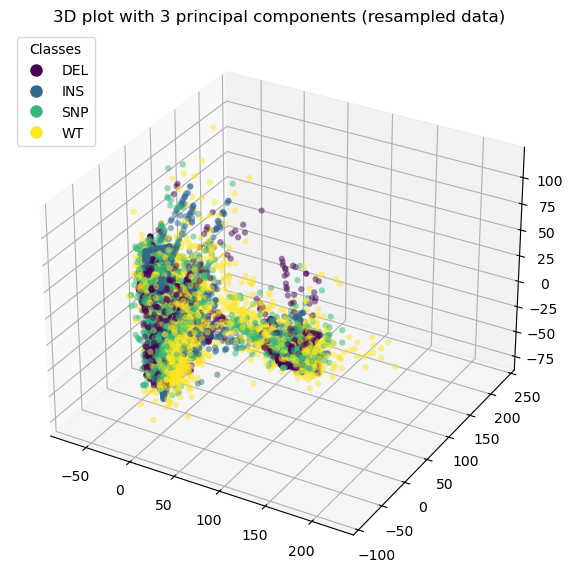

In [34]:
x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components (resampled data)")
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.show()


In these other 2 images, all four classes have similar numbers of data points, with DEL and INS significantly increased.

The resampling has made some patterns more apparent - particularly for DEL mutations (purple), which now show some distinct clustering in several regions. Indeed, DEL class (purple) now shows multiple small clusters, particularly visible in the 3D plot. This might indicate different subtypes of deletion mutations with distinct expression signatures.

## **Clustering**

In [36]:
y_true = y_res

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)


Accuracy: 0.2967
Adjusted Rand Index: 0.0121
Silhouette Score: 0.0705

PCA explained variance (first 2 components): [0.10705096 0.05271754]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_4314/1932342715.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)


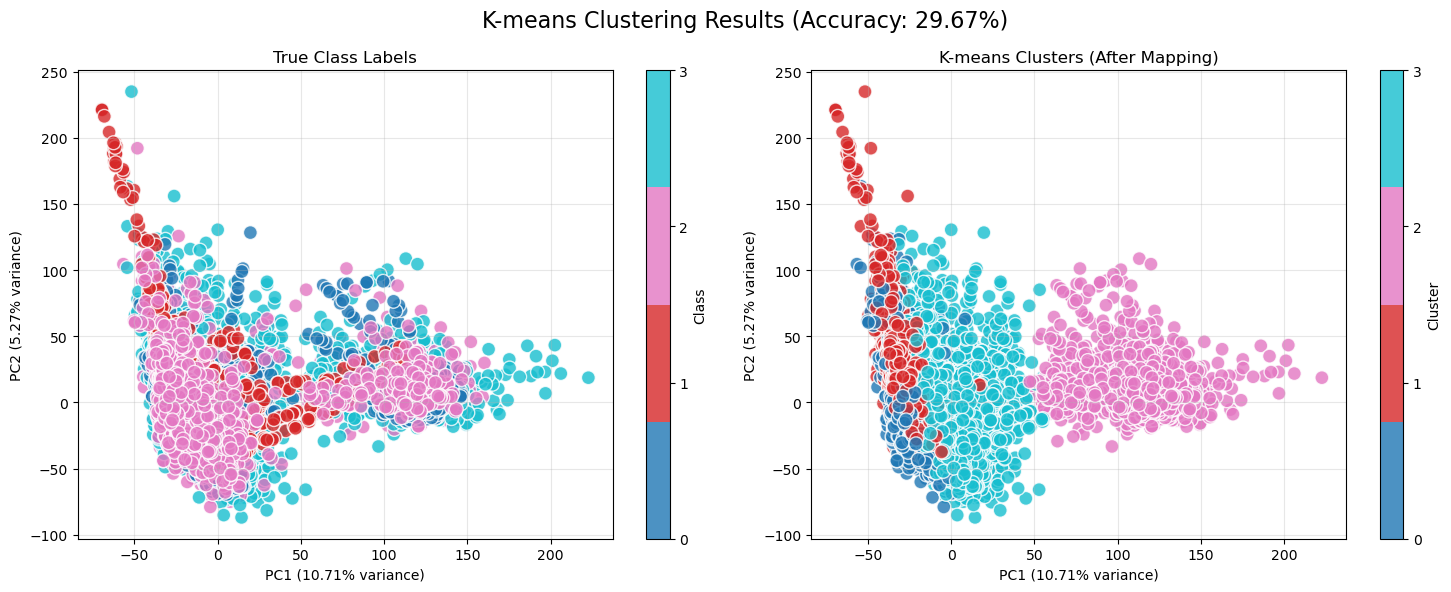

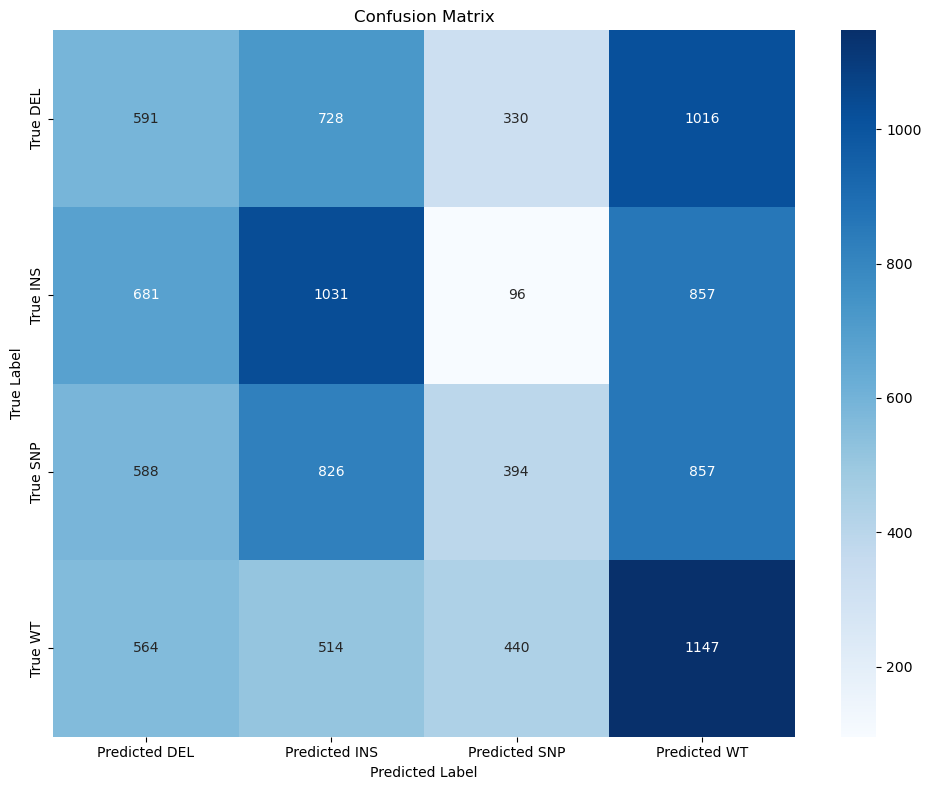

In [37]:


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)
n_classes = 4

def find_best_mapping(y_true, y_pred, n_classes):

    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    mapping = {old: new for old, new in zip(col_ind, row_ind)}
    
    y_pred_mapped = np.array([mapping[p] for p in y_pred])
    
    return y_pred_mapped, mapping


y_pred_mapped, cluster_mapping = find_best_mapping(y_true, y_pred, n_classes)

accuracy = accuracy_score(y_true, y_pred_mapped)
ari = adjusted_rand_score(y_true, y_pred)
silhouette = silhouette_score(X_scaled, y_pred)


cm = confusion_matrix(y_true, y_pred_mapped)


print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

n_components = min(50, X_scaled.shape[1]) 
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance (first 2 components): {pca.explained_variance_ratio_[:2]}")

cmap = plt.cm.get_cmap('tab10', n_classes)


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('True Class Labels')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Class', ticks=range(n_classes))
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_mapped, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('K-means Clusters (After Mapping)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Cluster', ticks=range(n_classes))
plt.grid(alpha=0.3)

plt.suptitle(f'K-means Clustering Results (Accuracy: {accuracy:.2%})', fontsize=16)
plt.tight_layout()
#plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Predicted {class_names[i]}' for i in range(n_classes)],
            yticklabels=[f'True {class_names[i]}' for i in range(n_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
#plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()




The clustering accuracy has actually decreased from the multi-class task on CCLE 40.03% to 29.67%, which is only slightly better than random assignment (25% for 4 classes). This suggests that after SMOTE resampling, the classes have become even harder to separate.

From the confusion matrix we can say that WT class (wild type) has the highest number of correctly classified samples (1147), INS class shows decent clustering for some samples (1031 correctly classified). Instead, SNP class is very poorly captured (only 394 correctly classified), but, overall, all classes show substantial confusion with other classes.

## **Classifiers** 

Once we have a clear understanding of the data and we have cleaned it as much as possible, we can try and build a predictor of the mutation of TP53.

### **Step 1**
First, we try and classify on the whole dataset. For simplicity we implement the one that was working best on the same multi-class classification task, i.e. **SVM**.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
model = SVC(probability=True, random_state=42)


print(f"\nTraining...")


model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")


acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')



y_proba = model.predict_proba(X_test_scaled)

roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec_macro:.4f}")
print(f"Macro Recall: {rec_macro:.4f}")
print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Macro ROC AUC: {roc_auc_macro:.4f}")



Training...
Test accuracy: 0.9315
Accuracy: 0.9315
Macro Precision: 0.9319
Macro Recall: 0.9319
Macro F1 Score: 0.9319
Macro ROC AUC: 0.9877


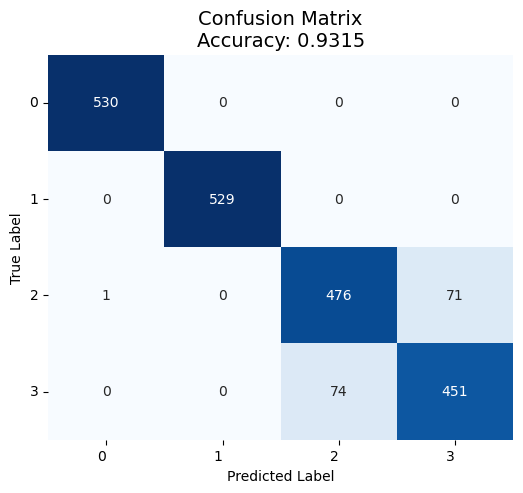

In [44]:
classification_report(y_test, y_pred, target_names=class_names, output_dict=True)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.xticks([0.5, 1.5], class_names, rotation=0, ha='right')
plt.yticks([0.5, 1.5], class_names, rotation=0)
plt.show()

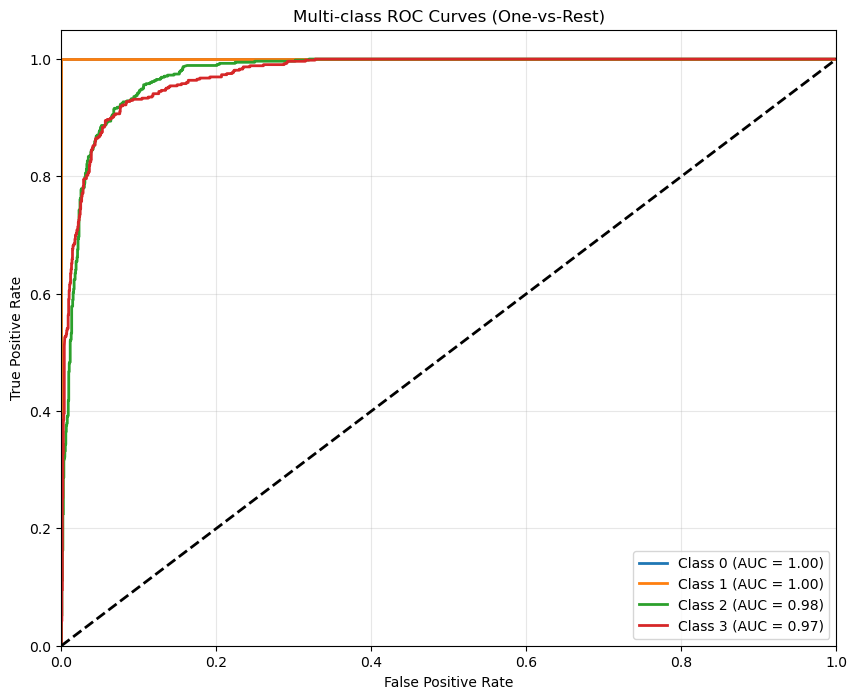

In [48]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
n_classes = len(np.unique(y_test))
classes = np.unique(y_test)
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


We have used Support Vector Machine which was the most performing meodel on the CCLE data. As a matter of fact, we want to see whether that model generalizes well also to this more complex dataset. Actually, we can see from the results that the generalization is pretty good as we achieve test accuracy of 0.9315 on the entire dataset.

### **Feature Importance**

In [49]:
if len(np.unique(y_train)) > 2:
    plt.figure(figsize=(15, 10))
    n_classes = len(np.unique(y_train))
    for i in range(n_classes):
        plt.subplot(2, (n_classes+1)//2, i+1)

        feature_names = X_train.columns
        class_importances = np.abs(model.coef_[i])
        class_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': class_importances
        })
        
        top_features = class_importance_df.sort_values('Importance', ascending=False).head(5)
        
        plt.barh(range(len(top_features)), top_features['Importance'])
        plt.yticks(range(len(top_features)), top_features['Feature'])
    
        plt.title(f'Top Features for Mutation Type: {class_names[i]}')
        plt.tight_layout()
    
    plt.suptitle('Class-Specific Feature Importance (Linear SVM)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## **Step2:** target genes

Now we repeat the classification task but only on a subset of features. In particular, we consider TP53 target genes (i.e. genes directly regulated by TP53).

In [ ]:
target_genes = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1', 'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1', 'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2', 'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79', 'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8', 'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1', 'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B']

In [ ]:
X_res_cleaned = X_res.rename(columns=lambda x: x.split('[')[0].split('(')[0].strip())
selected_columns = [col for col in X_res_cleaned.columns if col in target_genes]
X_res_target = X_res_cleaned[selected_columns]
X_res_target

In [ ]:
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_res_target, y_res, test_size=0.25, random_state=43, stratify=y_res
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_targ_scaled = scaler.fit_transform(X_train_target)
X_test_targ_scaled = scaler.transform(X_test_target)

In [ ]:
model.fit(X_train_targ_scaled, y_train_target)

y_pred_target = model.predict(X_test_targ_scaled)
test_accuracy = accuracy_score(y_test_target, y_pred_target)
print(f"Test accuracy: {test_accuracy:.4f}")

In [ ]:
cm = confusion_matrix(y_test_target, y_pred_target)
acc = accuracy_score(y_test_target, y_pred_target)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], class_names, rotation=0, ha='right')
plt.yticks([0.5, 1.5], class_names, rotation=0)
plt.show()


n_classes = len(np.unique(y_test_target))
print(f"Number of classes: {n_classes}")

y_pred_prob = model.predict_proba(X_test_targ_scaled)

roc_auc = roc_auc_score(y_test_target, y_pred_prob, multi_class='ovr', average='weighted')


classes = np.unique(y_test_target)
y_test_bin = label_binarize(y_test_target, classes=classes)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

f1 = f1_score(y_test_target, y_pred_target, average='weighted')
precision = precision_score(y_test_target, y_pred_target, average='weighted')
recall = recall_score(y_test_target, y_pred_target, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_target, y_pred_target))

## COMMENT